# Videjoegos, consolas, lanzamientos y ventas

# Explorar y limpiar datos

In [ ]:
import pandas as pd

df_games_dataset=pd.read_csv("games.csv")
df_games_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [67]:
df_games_dataset.nunique()

Name               11559
Platform              31
Year_of_Release       37
Genre                 12
NA_sales             402
EU_sales             307
JP_sales             244
Other_sales          155
Critic_Score          82
User_Score            96
Rating                 8
dtype: int64

In [72]:

df_games_dataset["Critic_Score"].unique()

array([76., nan, 82., 80., 89., 58., 87., 91., 61., 97., 95., 77., 88.,
       83., 94., 93., 85., 86., 98., 96., 90., 84., 73., 74., 78., 92.,
       71., 72., 68., 62., 49., 67., 81., 66., 56., 79., 70., 59., 64.,
       75., 60., 63., 69., 50., 25., 42., 44., 55., 48., 57., 29., 47.,
       65., 54., 20., 53., 37., 38., 33., 52., 30., 32., 43., 45., 51.,
       40., 46., 39., 34., 35., 41., 36., 28., 31., 27., 26., 19., 23.,
       24., 21., 17., 22., 13.])

In [4]:
df_games_dataset["User_Score"].unique()

array(['8', nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8',
       '6.1', '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6',
       '3.7', '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9',
       '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3',
       '2.7', '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0',
       '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
       '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'],
      dtype=object)

Aquí se detecta que todos los valores son números, excepto los nulos y "tbd"

In [5]:
df_games_dataset["Rating"].unique()

array(['E', nan, 'M', 'T', 'E10+', 'K-A', 'AO', 'EC', 'RP'], dtype=object)

In [6]:
df_games_dataset.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [7]:
#Convertir los encabezados en snake case (minúsculas)
df_games_dataset.columns =[col.lower() for col in df_games_dataset.columns]
df_games_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


En los datos hay un juego de plataforma "DS" que tiene como año de lanzamiento "1985".  
Esto, claramente es un error, ya que la DS fue lanzada en el año 2004.

In [8]:
#Corregir el año de lanzamiento de dicho juego (investigado en fuentes externas).
df_games_dataset.loc[df_games_dataset["name"]=="Strongest Tokyo University Shogi DS","year_of_release"]=2006

In [9]:
#Convertir la información correspondiente a tipo string
df_games_dataset["name"]=df_games_dataset["name"].astype(str)
df_games_dataset["platform"]=df_games_dataset["platform"].astype(str)
df_games_dataset["genre"]=df_games_dataset["genre"].astype(str)
df_games_dataset["rating"]=df_games_dataset["rating"].astype(str)

df_games_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16715 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           16715 non-null  object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


Las columnas "name", "platform", "genre" y "rating" contienen información que debe tomarse como str.

La columna "year_of_release" podría convertirse en fecha, pero ello añadirá mes/día/hora/minuto/segundo, lo cual no parece ser relevante en este análisis.

Al momento, es notoria la cantidad de datos faltantes en "critic_score" y "user_score", pero la acción a tomar depende del tipo de análisis.


En cuanto a la ausencia de algunos años de lanzamiento, puede deberse a
juegos hechos en una época donde la información no se documentaba del todo.


In [10]:
#En cuanto a abreviatura "tbd", se puede cambiar para manejar la columna como float: 
df_games_dataset["user_score"]=pd.to_numeric(df_games_dataset["user_score"], errors="coerce")
df_games_dataset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16715 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           16715 non-null  object 
dtypes: float64(7), object(4)
memory usage: 1.4+ MB


In [11]:
#Calcular ventas totales
df_games_dataset.sample(n=10)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
16497,Dungeon Explorer: Warriors of Ancient Arts,PSP,2007.0,Role-Playing,0.01,0.00,0.00,0.00,56.0,5.5,T
7373,HBO Boxing,PS,2000.0,Fighting,0.12,0.08,0.00,0.01,26.0,4.0,E
1056,No Man's Sky,PS4,2016.0,Action,0.63,0.76,0.03,0.27,71.0,4.5,T
4842,Boku no Natsuyasumi,PS,2000.0,Adventure,0.00,0.00,0.37,0.03,NaN,NaN,nan
1719,Gun,PS2,2005.0,Shooter,0.98,0.04,0.00,0.16,77.0,8.7,M
14096,World of Goo,PC,2008.0,Puzzle,0.00,0.03,0.00,0.01,90.0,8.5,E
4683,Itadaki Street DS,DS,2007.0,Misc,0.00,0.00,0.41,0.00,NaN,NaN,nan
15732,Kimikare: New Semester,PSP,2012.0,Action,0.00,0.00,0.02,0.00,NaN,NaN,nan
8814,Bomberman,DS,2005.0,Puzzle,0.10,0.01,0.03,0.01,75.0,7.0,E
11307,Jaws: Ultimate Predator,Wii,2011.0,Action,0.08,0.00,0.00,0.01,NaN,6.3,T


In [12]:
#Añadir una columna con la suma de las ventas de cada juego en las 4 columnas
df_games_dataset["total_sales"]=df_games_dataset["na_sales"]+df_games_dataset["eu_sales"]+df_games_dataset["jp_sales"]+df_games_dataset["other_sales"]

#Comprobar el añadido de la columna
df_games_dataset.info()
df_games_dataset.sample(n=10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16715 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           16715 non-null  object 
 11  total_sales      16715 non-null  float64
dtypes: float64(8), object(4)
memory usage: 1.5+ MB


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
10464,Escape From Monkey Island,PS2,2001.0,Adventure,0.05,0.04,0.00,0.01,84.0,8.2,T,0.10
16516,Railfan,PS3,2006.0,Simulation,0.00,0.00,0.01,0.00,NaN,NaN,nan,0.01
11876,Prey the Stars,DS,2008.0,Action,0.07,0.00,0.00,0.01,66.0,NaN,E,0.08
341,Tony Hawk's Pro Skater 4,PS2,2002.0,Sports,2.13,1.18,0.01,0.35,94.0,8.5,T,3.67
14204,Hitman: Blood Money,PC,2006.0,Action,0.00,0.03,0.00,0.01,82.0,8.8,M,0.04
3965,Unit 13,PSV,2012.0,Shooter,0.25,0.13,0.04,0.07,71.0,7.5,T,0.49
8286,Backyard Baseball '10,PS2,2009.0,Sports,0.08,0.07,0.00,0.02,NaN,NaN,E,0.17
3871,Cars 2,PS3,2011.0,Racing,0.22,0.21,0.00,0.09,NaN,NaN,nan,0.52
5581,Dead Rising 2: Off the Record,PS3,2011.0,Action,0.11,0.08,0.10,0.03,72.0,7.1,M,0.32
8932,Space Camp,DS,2009.0,Action,0.14,0.00,0.00,0.01,NaN,NaN,E,0.15


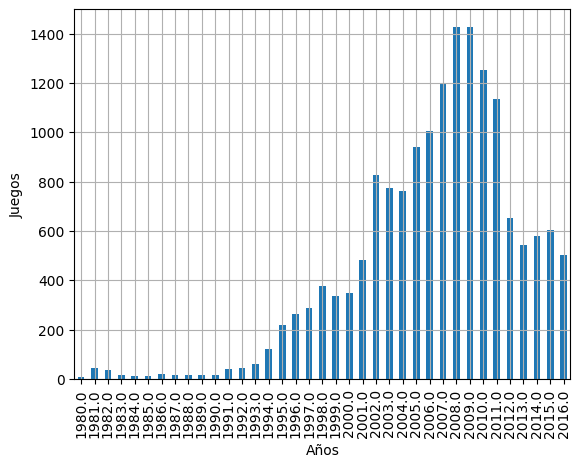

In [13]:
#Gráfica para visualizar cuántos juegos fueron lanzados en diferentes años
import matplotlib.pyplot as plt
df_games_years=df_games_dataset["year_of_release"].value_counts().sort_index()

df_games_years.plot(
    kind="bar",
    grid=True,
    xlabel="Años",
    ylabel="Juegos"
)

plt.show()

La gráfica hace evidente que la industria de los videojuegos incrementan su éxito y popularidad conforme pasa el tiempo.  
Los años 2008 y 2009 son los que más lanzamientos tienen debido al auge y estabilización de las consolas Xbox360, PS3 y Wii. 
 
En el año 2016 hubo menos de la mitad de lanzamientos que en el 2008 o 2009.  
Esto puede deberse a que los estudios optaron por calidad sobre cantidad. Es decir, menos juegos pero con más presupuesto y desarrollo.  
También puede deberse a la popularidad de juegos en línea que perduraron debido a su constante actualización y expansión.  
Otra posible razón es la presencia de juegos indie cuyo lanzamiento no siempre se registra.

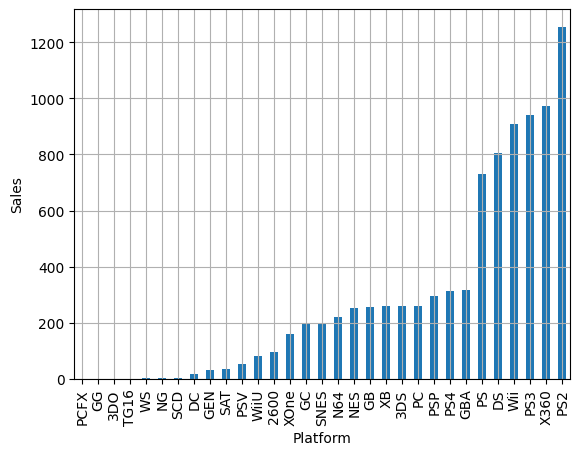

In [14]:
#Ordenar la cantidad de lanzamientos para cada consola, de mnor a mayor, y visualizarlo en gráfica
df_games_platforms_sales=df_games_dataset.groupby("platform")["total_sales"].sum().sort_values(ascending=True)

df_games_platforms_sales.plot(
    kind="bar",
    grid=True,
    xlabel="Platform",
    ylabel="Sales"
)

plt.show()

Las 6 consolas que más ventas de juegos han tenido son los 3 playstations, el nintendo DS, nintendo Wii y xbox360.  
Entre las consolas con menos ventas de juegos podemos encontrar algunas que tuvieron poca popularidad durante la etapa temprana de los videojuegos.  
Otras consolas tienen pocas ventas debido a que son relativamente recientes como el Xbox One y el WiiU.

In [15]:
#Filtrar el df solamente con las plataformas más populares
plataformas_top=["PS", "PS2", "PS3", "DS", "Wii", "X360"]
df_best_platforms =df_games_dataset[df_games_dataset["platform"].isin(plataformas_top)]

print(df_best_platforms["platform"].unique())
df_best_platforms.sample(n=10)


['Wii' 'DS' 'X360' 'PS3' 'PS2' 'PS']


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
8317,Country Dance: All Stars,X360,2012.0,Action,0.16,0.00,0.00,0.01,NaN,5.2,E10+,0.17
768,Hitman: Absolution,PS3,2012.0,Action,0.59,1.05,0.07,0.44,83.0,7.5,M,2.15
3656,Purr Pals,DS,2007.0,Simulation,0.18,0.35,0.00,0.02,67.0,6.8,E,0.55
16709,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,0.00,0.00,0.00,0.00,NaN,NaN,nan,0.00
6657,Minute to Win It,Wii,2010.0,Misc,0.23,0.00,0.00,0.02,NaN,3.0,E,0.25
8146,Splatterhouse,X360,2010.0,Action,0.14,0.03,0.00,0.01,62.0,7.6,M,0.18
16555,Heart no Kuni no Alice,PS2,2008.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,nan,0.01
2223,Guitar Hero: Metallica,Wii,2009.0,Misc,0.40,0.43,0.00,0.10,85.0,8.6,T,0.93
9631,Left Brain Right Brain 2,DS,2008.0,Misc,0.12,0.00,0.00,0.01,51.0,NaN,E,0.13
12218,Order Up!!,PS3,2011.0,Action,0.05,0.01,0.00,0.01,NaN,NaN,nan,0.07


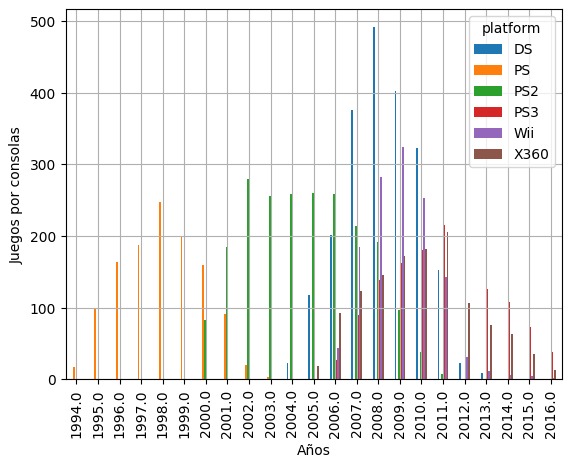

In [16]:
#Gráfica para visualizar la cantidad de lanzamientos para cada consola en cada año.

df_best_platforms_release=df_best_platforms.groupby(["year_of_release", "platform"])["name"].count().unstack()

df_best_platforms_release.plot(
    kind="bar",
    grid=True,
    xlabel="Años",
    ylabel="Juegos por consolas"
)
plt.show()

In [17]:
#"¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer?"

#Filtrar el df para obtener el año mínimo y máximo en cada consola respecto a los lanzamientos de sus respecivos juegos.
df_timeline=df_games_dataset.groupby("platform")["year_of_release"].agg(["min", "max"]).dropna().reset_index()

#Crear una nueva columna que contenga el "tiempo de vida" de cada consola.
df_timeline["lifespan"]=df_timeline["max"]-df_timeline["min"]

#Ordenar df por "año de nacimiento" de cada consola
df_timeline=df_timeline.sort_values("min",ascending=True)

df_timeline.info()
print("¬"*50)
print(df_timeline)
print("¬"*50)
print(df_timeline)

<class 'pandas.core.frame.DataFrame'>
Index: 31 entries, 0 to 30
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   platform  31 non-null     object 
 1   min       31 non-null     float64
 2   max       31 non-null     float64
 3   lifespan  31 non-null     float64
dtypes: float64(3), object(1)
memory usage: 1.2+ KB
¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬
   platform     min     max  lifespan
0      2600  1980.0  1989.0       9.0
11      NES  1983.0  1994.0      11.0
13       PC  1985.0  2016.0      31.0
5        GB  1988.0  2001.0      13.0
23     SNES  1990.0  1999.0       9.0
8       GEN  1990.0  1994.0       4.0
9        GG  1992.0  1992.0       0.0
22      SCD  1993.0  1994.0       1.0
12       NG  1993.0  1996.0       3.0
21      SAT  1994.0  1999.0       5.0
15       PS  1994.0  2003.0       9.0
1       3DO  1994.0  1995.0       1.0
24     TG16  1995.0  1995.0       0.0
14     PCFX  1996.0  1996.0       

De esta manera, se hace evidente que no hay plataforma cuyos lanzamientos hayan sucedido durante 14 años o más.  
El valor más grande en "lifespan" es el de "GB" con 13 años.  
Las consolas menos populares tienden a tener periodos de 2 años o menos.  
El lapso de tiempo más largo en el que no hubo lanzamientos de nuevas consolas fue entre 2006 y 2011.

Por la manera particular en la que funciona la PC en relación con los juegos, genera un valor atípico de 31 años.

¿Sería relevante diferenciar las plataformas por empresa?
¿Sería relevante diferenciar por tipo de plataforma? (sobremesa, portatil, híbrida)




## Construir un modelo para 2017

Llegado a este punto, el data frame "df_timeline" contiene información de las plataformas junto a los años de sus primeros y últimos lanzamientos de juegos.
El dataframe contiene información hasta el 2016.

Debido a eso, el que la columna "max" diga 2016, no necesariamnte significa que ese fue realmente el año de sus últimos lanzamientos.
La única consola para la que eso es cierto es "Wii".

Construir un modelo para el 2017 implica aplicarlo para las consolas con ["max"]==2016 excepto "wii".
Considero que dichas consolas deben ser separadas en dataframes para poder diferenciar entre el "pasado" y el año 2017.
También hay que eliminar la "PC" debido a que genera valores atípicos.

In [18]:
#Crear df del "pasado"
#Filtrar el df para excluir consolas de año máximo 2016 pero conservar la consola Wii
df_timeline_past=df_timeline[~((df_timeline["max"]==2016.0)&(df_timeline["platform"]!="Wii"))]

#Crear df del "futuro"
#Filtrar el df donde el año máximo de consolas sea 2016 excluyendo el Wii y PC
df_timeline_future=df_timeline[(df_timeline["max"]==2016.0)&(df_timeline["platform"]!="Wii")&(df_timeline["platform"]!="PC")]
print(df_timeline_past)
print("¬"*50)
print(df_timeline_future)

   platform     min     max  lifespan
0      2600  1980.0  1989.0       9.0
11      NES  1983.0  1994.0      11.0
5        GB  1988.0  2001.0      13.0
23     SNES  1990.0  1999.0       9.0
8       GEN  1990.0  1994.0       4.0
9        GG  1992.0  1992.0       0.0
22      SCD  1993.0  1994.0       1.0
12       NG  1993.0  1996.0       3.0
21      SAT  1994.0  1999.0       5.0
15       PS  1994.0  2003.0       9.0
1       3DO  1994.0  1995.0       1.0
24     TG16  1995.0  1995.0       0.0
14     PCFX  1996.0  1996.0       0.0
10      N64  1996.0  2002.0       6.0
3        DC  1998.0  2008.0      10.0
25       WS  1999.0  2001.0       2.0
6       GBA  2000.0  2007.0       7.0
29       XB  2000.0  2008.0       8.0
16      PS2  2000.0  2011.0      11.0
7        GC  2001.0  2007.0       6.0
4        DS  2004.0  2013.0       9.0
19      PSP  2004.0  2015.0      11.0
26      Wii  2006.0  2016.0      10.0
¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬¬
   platform     min     max  lifespan

Para calcular la probabilidad de que el año 2017 sea el último año de cada consola, se llevará a cabo con 3 enfoques diferentes;  

    1.-Por la frecuencia con la que las cantidades aparecen en "lifespan" del pasado.
    2.-Por el valor máximo de "lifespan" del pasado.
    3.-Por el promedio de "lifespan" del pasado.

In [19]:
#por frecuencia:
lifespans=df_timeline_past["lifespan"]
lifespan_counts=lifespans.value_counts().sort_index()
lifespan_distribution=lifespan_counts/lifespan_counts.sum()

def obsolete_probability(platform,actual_length):
    if actual_length in lifespan_distribution:
        return lifespan_distribution[actual_length]
    else:
        return 0.0

df_timeline_future["by_frequency"]=df_timeline_future["lifespan"].apply(lambda x: obsolete_probability(None, x))
print(df_timeline_future)



   platform     min     max  lifespan  by_frequency
28     X360  2005.0  2016.0      11.0      0.130435
17      PS3  2006.0  2016.0      10.0      0.086957
20      PSV  2011.0  2016.0       5.0      0.043478
2       3DS  2011.0  2016.0       5.0      0.043478
27     WiiU  2012.0  2016.0       4.0      0.043478
18      PS4  2013.0  2016.0       3.0      0.043478
30     XOne  2013.0  2016.0       3.0      0.043478


C:\Users\Felipe Rodriguez\AppData\Local\Temp\ipykernel_15748\1874334689.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_timeline_future["by_frequency"]=df_timeline_future["lifespan"].apply(lambda x: obsolete_probability(None, x))


In [20]:
#por valor máximo:
max_lifespan=13
df_timeline_future["by_max_lifespan"]=df_timeline_future["lifespan"]/max_lifespan
print(df_timeline_future)

   platform     min     max  lifespan  by_frequency  by_max_lifespan
28     X360  2005.0  2016.0      11.0      0.130435         0.846154
17      PS3  2006.0  2016.0      10.0      0.086957         0.769231
20      PSV  2011.0  2016.0       5.0      0.043478         0.384615
2       3DS  2011.0  2016.0       5.0      0.043478         0.384615
27     WiiU  2012.0  2016.0       4.0      0.043478         0.307692
18      PS4  2013.0  2016.0       3.0      0.043478         0.230769
30     XOne  2013.0  2016.0       3.0      0.043478         0.230769


C:\Users\Felipe Rodriguez\AppData\Local\Temp\ipykernel_15748\3272073023.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_timeline_future["by_max_lifespan"]=df_timeline_future["lifespan"]/max_lifespan


In [21]:
#por promedio:
mean_lifespan=df_timeline_future["lifespan"].mean()
df_timeline_future["by_lifespan_mean"]=df_timeline_future["lifespan"]/mean_lifespan
print(df_timeline_future)

   platform     min     max  lifespan  by_frequency  by_max_lifespan  \
28     X360  2005.0  2016.0      11.0      0.130435         0.846154   
17      PS3  2006.0  2016.0      10.0      0.086957         0.769231   
20      PSV  2011.0  2016.0       5.0      0.043478         0.384615   
2       3DS  2011.0  2016.0       5.0      0.043478         0.384615   
27     WiiU  2012.0  2016.0       4.0      0.043478         0.307692   
18      PS4  2013.0  2016.0       3.0      0.043478         0.230769   
30     XOne  2013.0  2016.0       3.0      0.043478         0.230769   

    by_lifespan_mean  
28          1.878049  
17          1.707317  
20          0.853659  
2           0.853659  
27          0.682927  
18          0.512195  
30          0.512195  


C:\Users\Felipe Rodriguez\AppData\Local\Temp\ipykernel_15748\3192739476.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_timeline_future["by_lifespan_mean"]=df_timeline_future["lifespan"]/mean_lifespan


# Podría el 2017 ser el último año para las consolas?
En los 3 casos se hace evidente que las consolas con mayor probabilidad de terminar en el 2017 son "X360" y "PS3".

In [22]:
df_games_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16715 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           16715 non-null  object 
 11  total_sales      16715 non-null  float64
dtypes: float64(8), object(4)
memory usage: 1.5+ MB


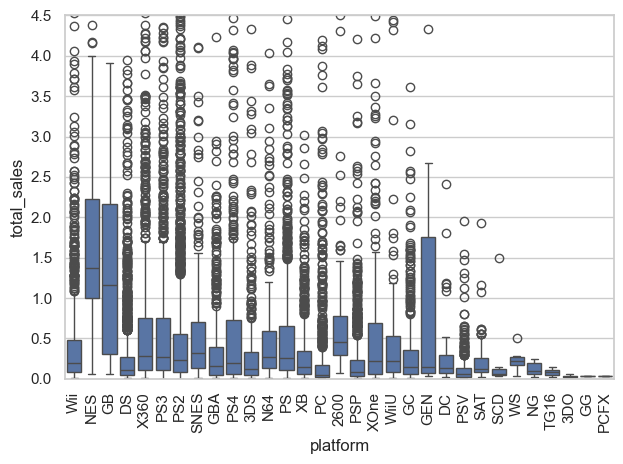

In [23]:
#"Crea un diagrama de caja para las ventas globales de todos los juegos, desglosados por plataforma."
import seaborn as sns

sns.set_theme(style="whitegrid")
sns.boxplot(
    data=df_games_dataset,
    x="platform",
    y="total_sales")

plt.xticks(rotation=90)
plt.ylim(0, 4.5)
plt.tight_layout()



La gráfica con diagramas de caja, en este caso, tuvo que ser limitada, ya que hay valores atípicos que provocan que los diagramas de caja se "aplasten" demasiado y sea muy dificil de leer.  Específicamente, el valor atípico más alto se encuentra en la consola Wii y se trata del juego Wii Sports, con 82.9 millones de ventas.

Es frecuente que en las ventas de juegos de cada consola, los valores superiores a las medianas estén más dispersos.  
También, abundan los valores atípicos.  

Al comparar los diagramas de caja entre Wii y NES, se hace evidente que la mayoría de los juegos de Wii venden poco, pero unos cuantos juegos de Wii venden muchísimo y es lo que hace que supere a las demás consolas en ventas.  
Los juegos de NES han tenido ventas más estables, pero su valor atípico más alto corresponde a Super Mario Bros  con 40 millones de copias.

Por último, se vuelve eviedente que la empresa lider en ventas es Nintendo.
Las consolas en los primeros 4 lugares son de Nintendo.

# Reseñas VS Ventas

Las reseñas de usuarios y profesionales afectan las ventas de los juegos?  
Averigüemoslo en la plataforma Xbox 360

<Axes: xlabel='user_score', ylabel='total_sales'>

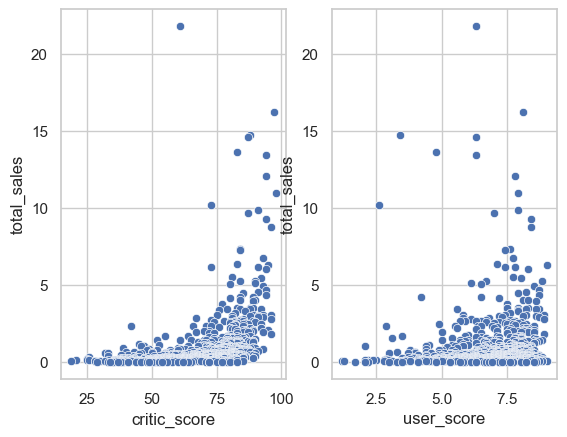

In [24]:
#Filtrar el df para quedarnos únicamente con los datos de x360
df_x360=df_games_dataset[df_games_dataset["platform"]=="X360"]
#Eliminar las filas donde falten datos en las columnas de resñas de usuarios, reseñas de críticos y ventas totales
df_x360_clean=df_x360.dropna(subset=["critic_score","user_score","total_sales"])

#Crear gráficos de dispersión con las reseñas de críticos
plt.subplot(1, 2, 1)
sns.scatterplot(
    data=df_x360_clean,
    x="critic_score",
    y="total_sales"
)

#Crear gráfico de dispersión con las reseñas de usuarios
plt.subplot(1, 2, 2)
sns.scatterplot(
    data=df_x360_clean,
    x="user_score",
    y="total_sales"
)





In [25]:
#Calcular la correlación entre las reseñas y las ventas para ambos casos

corr_critic=df_x360_clean["critic_score"].corr(df_x360_clean["total_sales"])
corr_user=df_x360_clean["user_score"].corr(df_x360_clean["total_sales"])

print(f"Correlación entre reseñas de críticos y ventas:{corr_critic:.4f}")
print(f"Correlación entre reseñas de usuarios y ventas:{corr_user:.4f}")


Correlación entre reseñas de críticos y ventas:0.3895
Correlación entre reseñas de usuarios y ventas:0.1104


Las reseñas de los críticos es más fuerte en las ventas que las reseñas de usuarios.  
Sin embargo, ninguna es de 0.5 o mayor, lo que indica que hay otros factores con mayor influencia en las ventas de los juegos (al menos en cuanto a Xbox 360).

Tanto el puntaje por parte de críticos como por parte de los usuarios tiene influencia en las ventas de cada juego.
Sin embargo, el puntaje por parte de los críticos es el que tiene mayor peso.

## Plataforma VS Plataforma

Comparar las ventas de los mismos juegos entre diferentes consolas

<Axes: xlabel='x360_sales', ylabel='ps3_sales'>

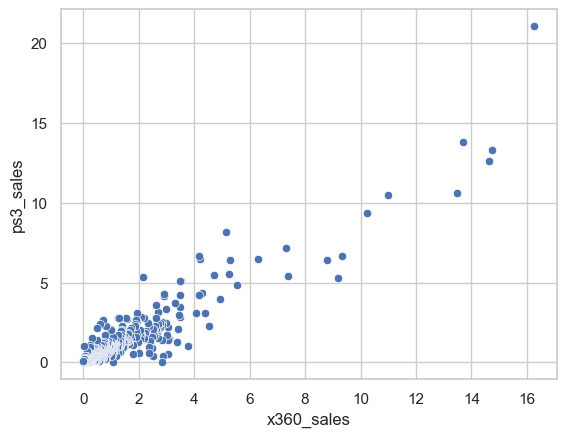

In [26]:
#Filtrar DataFrames para quedarnos con la información de las dos consolas
df_x360_vs=df_games_dataset[df_games_dataset["platform"]=="X360"]
df_ps3_vs=df_games_dataset[df_games_dataset["platform"]=="PS3"]

#Crear set únicamente con los juegos comunes entre ambas consolas
common_names=set(df_x360_vs["name"]).intersection(df_ps3_vs["name"])

#Filtrar los DataFrames para que tengan únicamente los juegos en común (usando el set)
df_x360_common=df_x360_vs[df_x360_vs["name"].isin(common_names)]
df_ps3_common=df_ps3_vs[df_ps3_vs["name"].isin(common_names)]

#Renombrar la columna "ventas totales" en cada df para diferenciarlas
df_x360_common=df_x360_common[["name","total_sales"]].rename(columns={"total_sales":"x360_sales"})
df_ps3_common=df_ps3_common[["name","total_sales"]].rename(columns={"total_sales":"ps3_sales"})

#Unir los DataFrames por la columna con los nombres de juegos
df_x360_vs_ps3=pd.merge(df_x360_common,df_ps3_common,on="name")

#Visualizar la comparación con gráfico de dispersión
sns.scatterplot(
    data=df_x360_vs_ps3,
    x="x360_sales",
    y="ps3_sales"
)




Al comparar las ventas de los juegos en común entre x360 y ps3, se nota que dichos juegos tuvieron un nivel de éxito similar en ambas plataformas.

<Axes: xlabel='x360_sales', ylabel='wii_sales'>

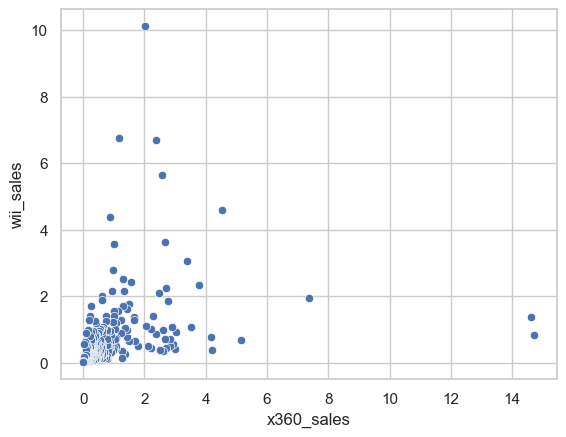

In [27]:
#Comparar las ventas de los mismos juegos en otras plataformas

#Separar DataFrames
df_x360_vs=df_games_dataset[df_games_dataset["platform"]=="X360"]
df_wii_vs=df_games_dataset[df_games_dataset["platform"]=="Wii"]

#Set con juegos en común
common_names=set(df_x360_vs["name"]).intersection(df_wii_vs["name"])

#Filtrar usando el set
df_x360_common=df_x360_vs[df_x360_vs["name"].isin(common_names)]
df_wii_common=df_wii_vs[df_wii_vs["name"].isin(common_names)]

#Cambiar el nombre de columnas de ventas
df_x360_common=df_x360_common[["name","total_sales"]].rename(columns={"total_sales":"x360_sales"})
df_wii_common=df_wii_common[["name","total_sales"]].rename(columns={"total_sales":"wii_sales"})

#Unir DataFrames
df_x360_vs_wii=pd.merge(df_x360_common,df_wii_common,on="name")

#Gráfico de dispersión
sns.scatterplot(
    data=df_x360_vs_wii,
    x="x360_sales",
    y="wii_sales"
)


A diferencia de la comparación anterior, los mismos juegos entre x360 y wii tienden a tener más ventas en una plataforma que en la otra.  
Una psoible razón es que las plataformas en cuestión se asocian con géneros de juegos distintos.

## Analizar por géneros

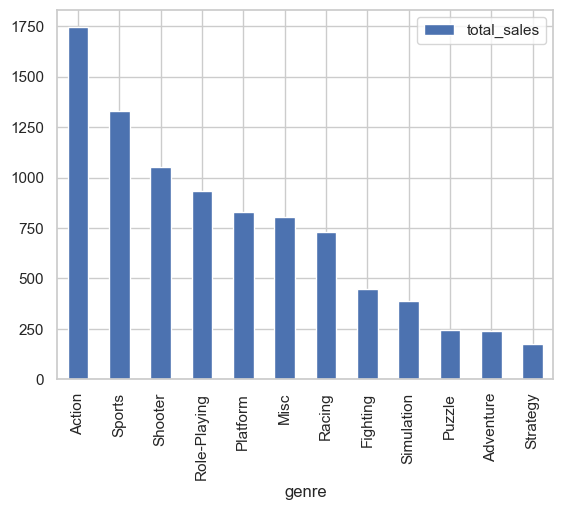

           genre  total_sales
0         Action      1744.17
10        Sports      1331.27
8        Shooter      1052.45
7   Role-Playing       934.56
4       Platform       827.77
3           Misc       802.51
6         Racing       728.67
2       Fighting       447.53
9     Simulation       389.97
5         Puzzle       242.57
1      Adventure       237.59
11      Strategy       174.23


In [28]:
#Ventas totales de cada género

#Borrar las filas de género "nan" (como str)
df_games_dataset_genres_clean=df_games_dataset[df_games_dataset["genre"] != "nan"]

#Agrupar por géneros y sumar las respectivas ventas totales
df_genre_sales=df_games_dataset_genres_clean.groupby("genre",as_index=False)["total_sales"].sum()
df_genre_sales=df_genre_sales.sort_values(by="total_sales",ascending=False)


#Gráfica de barras
df_genre_sales.plot(
    kind="bar",
    x="genre",
    y="total_sales"
)
plt.show()
print(df_genre_sales)

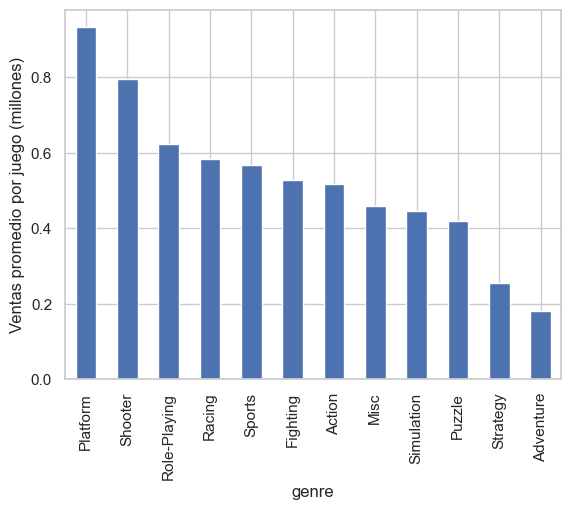

           genre  total_sales
4       Platform     0.932173
8        Shooter     0.795503
7   Role-Playing     0.623872
6         Racing     0.583403
10        Sports     0.566980
2       Fighting     0.527126
0         Action     0.517711
3           Misc     0.458577
9     Simulation     0.446701
5         Puzzle     0.418224
11      Strategy     0.255095
1      Adventure     0.182341


In [29]:
#Ventas promedio de cada género

df_genres_avg=df_games_dataset_genres_clean.groupby("genre")[["total_sales"]].mean().reset_index()
df_genres_avg=df_genres_avg.sort_values(by="total_sales", ascending=False)

df_genres_avg.plot(
    kind="bar",
    x="genre",
    y="total_sales",
    grid=True,
    legend=False
)

plt.ylabel("Ventas promedio por juego (millones)")
plt.show()
print(df_genres_avg)


Aquí se pueden observar dos enfoques distintos.  
Al sumar las ventas totales en cada género, los  más exitosos son los de acción, seguido por deportes, disparos, de rol y plataformero.

Sin embargo, al agrupar los juegos por géneros y promediar las ventas totales de cada uno, el género más rentable es plataformero, seguido por disparos, de rol, carreras y deportes.

Por otro lado, los géneros con menos éxito tanto en ventas totales como en ventas promedio, son estrategia y aventura.

## Plataformas de mayor éxito en diferentes países

Determinar las 5 plataformas principales en cada regíon (NA, EU, JP)

In [30]:
#Agrupar por plataforma y sumar las ventas de cada región
df_nations=df_games_dataset.groupby("platform")[["na_sales","eu_sales","jp_sales"]].sum().reset_index()

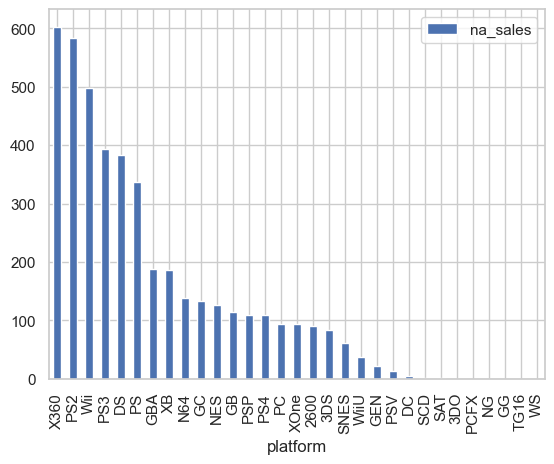

In [31]:
#Norteamérica

#Ordenar por ventas en "na"
df_nations=df_nations.sort_values(by="na_sales",ascending=False)
df_nations.plot(
    kind="bar",
    x="platform",
    y="na_sales",
    grid=True
)

plt.show()


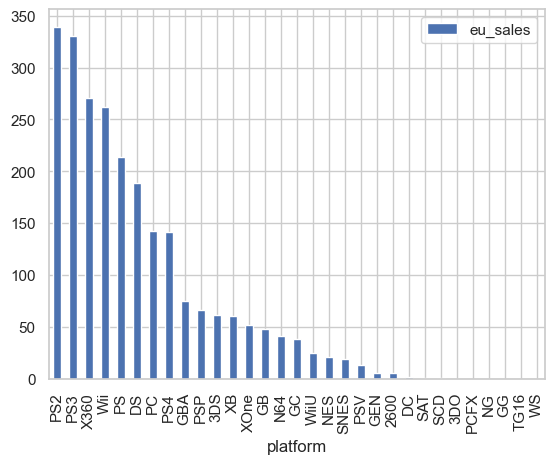

In [32]:
#Europa

#Ordenar por ventas en "eu"
df_nations=df_nations.sort_values(by="eu_sales",ascending=False)
df_nations.plot(
    kind="bar",
    x="platform",
    y="eu_sales",
    grid=True
)

plt.show()

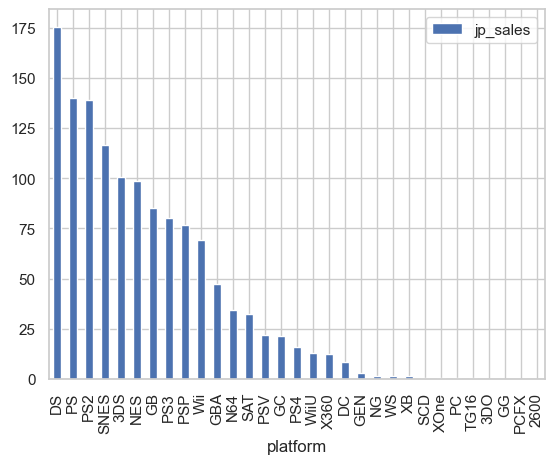

In [33]:
df_nations=df_nations.sort_values(by="jp_sales",ascending=False)
df_nations.plot(
    kind="bar",
    x="platform",
    y="jp_sales",
    grid=True
)

plt.show()

## América del norte:
X360  
PS2  
Wii  
PS3  
DS




## Europa:
PS2  
PS3  
X360  
Wii  
PS

## Japón:
DS  
PS  
PS2  
SNES  
3DS

En japón es más marcada la preferencia por nintendo.  
Consolas como la X360 y la PS3 tienen más ventas en occiedente que en oriente.

# Géneros más populares en distintos países

In [34]:
#Agrupar por géneros y sumar las ventas de cada región
df_genres=df_games_dataset_genres_clean.groupby("genre")[["na_sales","eu_sales","jp_sales"]].sum().reset_index()

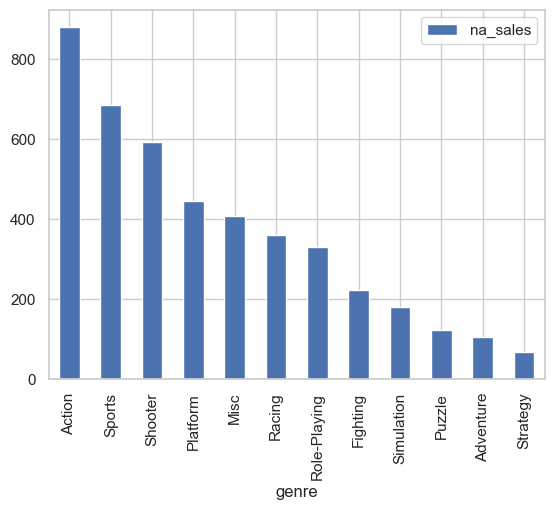

In [35]:
#Norteamérica

df_genres=df_genres.sort_values(by="na_sales",ascending=False)
df_genres.plot(
    kind="bar",
    x="genre",
    y="na_sales",
    grid=True
)

plt.show()

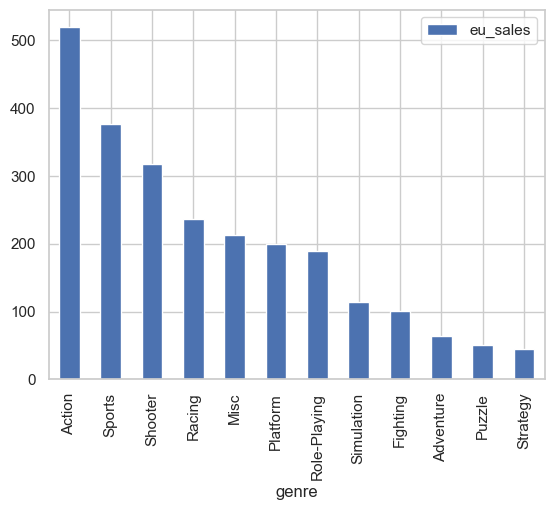

In [36]:
#Europa

df_genres=df_genres.sort_values(by="eu_sales",ascending=False)
df_genres.plot(
    kind="bar",
    x="genre",
    y="eu_sales",
    grid=True
)

plt.show()

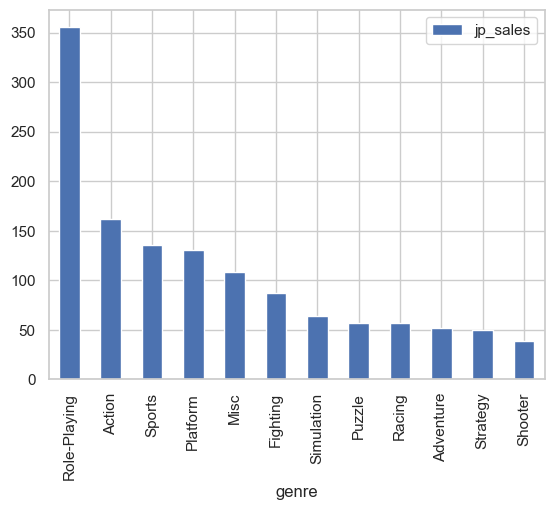

In [37]:
#Japón

df_genres=df_genres.sort_values(by="jp_sales",ascending=False)
df_genres.plot(
    kind="bar",
    x="genre",
    y="jp_sales",
    grid=True
)

plt.show()

# Norteamérica
 Acción  
 Deportes  
 Disparos  
 Plataformero  
 Miscelaneo  


# Europa
Acción  
Deportes  
Disparos  
Carreras  
Miscelaneo


# Japón
De rol  
Acción  
Deportes  
Plataformero  
Miscelaneo

En los tres casos, el quinto género más popular es Miscelaneo. Sin embargo, dicho término es demasiado ambiguo. Podría subdividirse en géneros más específicos y ello podría cambiar los resultados. en los 3 casos.

Cabe señalar que la preferecnia japonesa por los juegos de rol es más del doble que su preferencia por los juegos de acción.


# Preferencias por clasificaciones ESRB

In [38]:
#Agrupar por clasificaciones y sumar ventas por región
df_ratings=df_games_dataset.groupby("rating")[["na_sales","eu_sales","jp_sales"]].sum().reset_index()

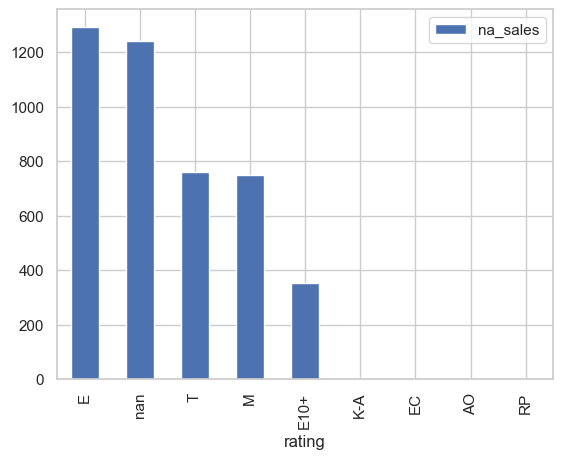

In [39]:
#Norteamérica

df_ratings=df_ratings.sort_values(by="na_sales",ascending=False)
df_ratings.plot(
    kind="bar",
    x="rating",
    y="na_sales",
    grid=True
)

plt.show()

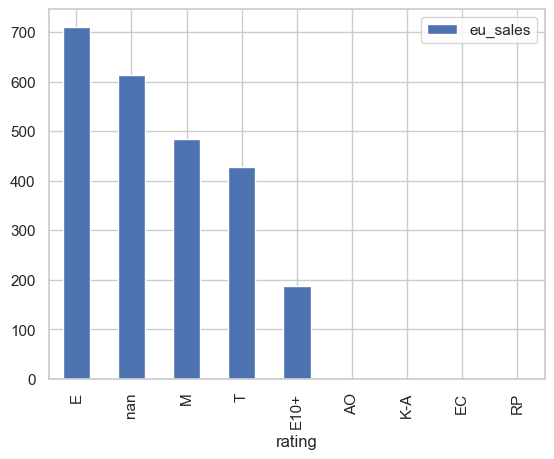

In [40]:
#Europa
df_ratings=df_ratings.sort_values(by="eu_sales",ascending=False)
df_ratings.plot(
    kind="bar",
    x="rating",
    y="eu_sales",
    grid=True
)

plt.show()

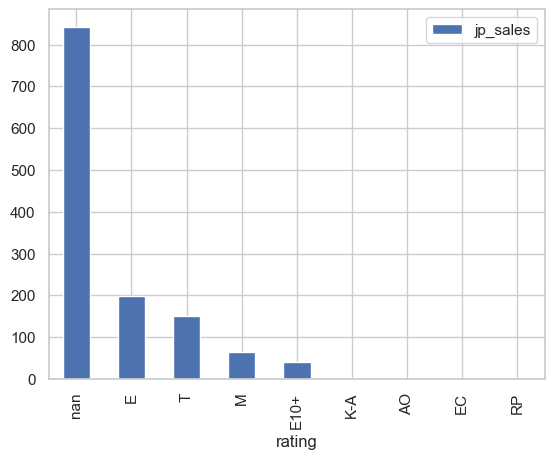

In [41]:
#Japón
df_ratings=df_ratings.sort_values(by="jp_sales",ascending=False)
df_ratings.plot(
    kind="bar",
    x="rating",
    y="jp_sales",
    grid=True
)

plt.show()


In [42]:
print(df_games_dataset["rating"].value_counts())

rating
nan     6766
E       3990
T       2961
M       1563
E10+    1420
EC         8
K-A        3
RP         3
AO         1
Name: count, dtype: int64


La cantidad de juegos que no tienen clasificación en la base de datos es mucho más grande que en el resto de las clasificaciones.  
Un posible motivo es que la ESRB fue fundada en 1994 pero la consola más antigua en el df es la NES de 1983.    
Al tener las clasificaciones completas se podrían obtener resultados diferentes.  

Pero con la información disponible, podemos ver que en las tres regiones, se prefieren juegos clasificación "E".
Cabe mencionar que japón tiene la mayor preferencia por juegos sin clasicficación.

# t-tests

1.-Comprobar si las calificaciones promedio de Xbox one y PC por parte de los usuarios son las mimsas.

2.-Comprobar si las calificaciones promedio de los juegos de acción y deportes son las mismas por parte de los usuarios.

In [ ]:
#Comprobar diferencia de varianzas
from scipy.stats import levene

xone_scores=df_games_dataset[df_games_dataset["platform"]=="XOne"]["user_score"].dropna()
pc_scores =df_games_dataset[df_games_dataset["platform"]=="PC"]["user_score"].dropna()

stat, p_value=levene(xone_scores, pc_scores)
print(f"Estadístico de Levene: {stat:.8f}")
print(f"p-value: {p_value:.8f}")

Estadístico de Levene: 1.2213
p-value: 0.2694


No hay evidencia de que las varienzas sean diferentes.  
Se usará equal_var=True.

In [ ]:
#H₀: Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.
from scipy.stats import ttest_ind

alpha=0.05
t_stat1, p_val1 =ttest_ind(
    xone_scores,
    pc_scores,
    equal_var=True)

print(f"t = {t_stat1:.8f}, p = {p_val1:.8f}")


t = -4.36833382, p = 0.00001390


Las calificaciones de los usuarios de Xbox one y PC son diferentes.
Se rechaza la hipótesis nula.

In [60]:
#H₀: Las calificaciones promedio de los usuarios para los géneros Acción y Deportes son iguales.
action_scores=df_games_dataset[df_games_dataset["genre"]=="Action"]["user_score"].dropna()
sports_scores=df_games_dataset[df_games_dataset["genre"]=="Sports"]["user_score"].dropna()


stat2, p_value1=levene(action_scores, sports_scores)
print(f"Estadístico de Levene: {stat2:.8f}")
print(f"p-value: {p_value1:.8f}")


Estadístico de Levene: 14.13289609
p-value: 0.00017366


No hay evidencia de que las varienzas sean diferentes.  
Se usará equal_var=True.

In [62]:
alpha=0.05
t_stat2, p_val2=ttest_ind(
    action_scores,
    sports_scores,
    equal_var=True)

print(f"t = {t_stat2:.4f}, p = {p_val2:.4f}")

t = 1.6259, p = 0.1041


En promedio, los juegos de acción tienen calificaciones similares a deportes por parte de los usuarios.  
No se rechaza la hipótesis nula.

# Conclusiones

Se utilizó un dataset de 16,715 filas que contiene información sobre videojuegos, sus nombres, sus años de lanzamiento, sus plataformas, sus géneros, sus ventas, sus calificaciones por reseñas de usuarios y críticos, y su clasificación.

En muchos aspectos del análisis, se optó por excluir la plataforma PC, ya que genera valores atípicos.

Después de limpiar los datos, se añadió una columna con la suma de las ventas.

Al analizar la cantidad de lanzamientos de juegos en cada año, se encontró que la cantidad de lanzamientos fue incrementando hasta 2008 y 2009, donde hubo más lanzamientos. 

En años posteriores, las compañías optaron por menos lanzamientos pero mayor desarrollo y actualización.

Las 6 consolas que más ventas de juegos han tenido son los 3 playstations, el nintendo DS, nintendo Wii y xbox360.  

Las consolas tienden a tener un “tiempo de vida” de menos de 10 años.

El GB es la consola qué tuvo lanzamientos durante más tiempo, 13 años.

Al comparar las ventas de cada consola a través de diagramas de caja, se notó que mucho del éxito de cada consola depende de unos cuantos juegos con cantidades de ventas atípicas. Es decir, pocos juegos que venden mucho.

Las reseñas influyen en las ventas de videojuegos, pero la opinión de los críticos tiene un poco de mayor peso que la de los usuarios. Pero nada de eso es lo que más influye en las ventas.

Hay juegos que son lanzados para dos o más plataformas, pero en ocasiones, el mismo juego puede tener más éxito en una que en otra.

Entre las regiones se pueden detectar diferencias tanto de consolas como de géneros. Pero la región con preferencias más diferentes es Japón, su preferencia por consolas y géneros es distinta a las de Norteamérica y Europa.

Muchos juegos no tienen clasificación, y debido a ello resulta difícil llegar a conclusiones concretas acerca de ese tema.
